In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # fix Mac M4 kernel crash
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'    # use GPU 0,1 only

import sys
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# pick device (cuda:0 maps to physical GPU 0 under CUDA_VISIBLE_DEVICES)
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [7]:
from torchvision import datasets
from torchvision import transforms
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True,
    transform=basic_transform
)
test_dataset = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=True,
    transform=basic_transform
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))
print("Classes:", train_dataset.classes)

Train: 50000
Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [24]:
class_names = train_dataset.classes
for index, class_name in enumerate(class_names):
    print(index, class_name)

num_classes = len(class_names)

assert (
    train_dataset.classes
    == test_dataset.classes
)

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


In [25]:
sample_image, sample_label = train_dataset[0]
print("Image shape:", sample_image.shape)
print("Image dtype:", sample_image.dtype)
print("Pixel minimum:", sample_image.min().item())
print("Pixel maximum:", sample_image.max().item())

print("Label:", sample_label)
print("Class:", class_names[sample_label])

Image shape: torch.Size([3, 32, 32])
Image dtype: torch.float32
Pixel minimum: 0.0
Pixel maximum: 1.0
Label: 6
Class: frog


In [ ]:
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)
print("First labels:", labels[:10])

Images: torch.Size([64, 3, 32, 32])
Labels: torch.Size([64])
First labels: tensor([8, 1, 1, 3, 4, 1, 5, 2, 0, 3])


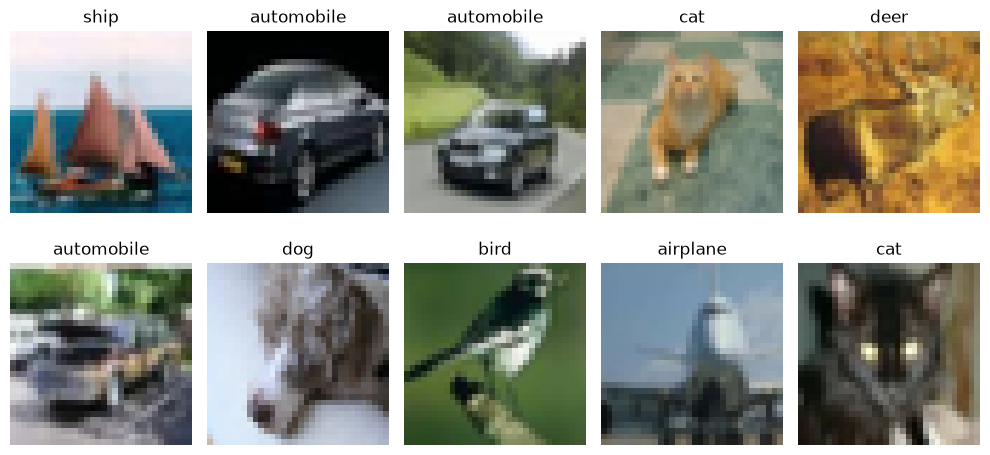

In [27]:
import matplotlib.pyplot as plt
figure, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5)
)

for axis, image, label in zip(
    axes.flatten(),
    images[:10],
    labels[:10]
):
    display_image = image.permute(
        1,
        2,
        0
    )

    axis.imshow(display_image)

    axis.set_title(
        class_names[label.item()]
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

In [31]:
import torch
import torch.nn as nn
class CIFAR10MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # [batch,3,32,32]
        #        ↓
        # [batch,3072]
        self.flatten = nn.Flatten()

        # [batch,3072]
        #        ↓
        # [batch,128]
        self.hidden = nn.Linear(3 * 32 * 32, 128)

        self.relu = nn.ReLU()
        # [batch,128]
        #       ↓
        # [batch,10]
        self.output = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        logits = self.output(x)

        return logits

torch.manual_seed(42)
model = CIFAR10MLP(num_classes=num_classes) # 10
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)



In [ ]:
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# setup hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 20

# prepare CIFAR10 dataset
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

training_data = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True,
    transform=basic_transform
)
test_data = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=True,
    transform=basic_transform
)

# organize to DataLoader
train_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)



# define class:
class CIFAR10MLP(nn.Module):
    # initation --- layers setup
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(3 * 32 * 32, 128)
        self.relu = nn.ReLU()
        self.output = nn.Linear(128, 10)

    # put layers together
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        logits = self.output(x)
        return logits

# create model --- setup loss function and optimizer
model = CIFAR10MLP()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# define training epoch function
def train_one_epoch(model, data_loader, loss_fn, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size # multiply batch_size because loss.item() is the average of the batch.
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples


    return epoch_loss, epoch_accuracy

# define evaluation function
def evaluate(model, data_loader, loss_fn):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            logits = model(images)
            loss = loss_fn(logits, labels)
            predictions = logits.argmax(dim=1)
            # sum each batch's loss
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

        test_loss = total_loss / total_samples
        test_accuracy = total_correct / total_samples

    return test_loss, test_accuracy

# history record
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

for epoch in range(num_epochs):
    # train one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer
    )

    # evaluate on test set
    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        loss_fn
    )

    # record history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    # print progress
    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"train loss={train_loss:.4f}, "
        f"train accuracy={train_accuracy:.2%}, "
        f"test loss={test_loss:.4f}, "
        f"test accuracy={test_accuracy:.2%}"
    )

Epoch 1/20, train loss=1.8760, train accuracy=32.53%, test loss=1.7608, test accuracy=36.39%
Epoch 2/20, train loss=1.7273, train accuracy=38.18%, test loss=1.6693, test accuracy=40.85%
Epoch 3/20, train loss=1.6660, train accuracy=40.56%, test loss=1.6734, test accuracy=40.09%
Epoch 4/20, train loss=1.6244, train accuracy=42.41%, test loss=1.6453, test accuracy=41.43%
Epoch 5/20, train loss=1.5896, train accuracy=43.64%, test loss=1.6205, test accuracy=41.99%
Epoch 6/20, train loss=1.5608, train accuracy=44.65%, test loss=1.5803, test accuracy=44.20%
Epoch 7/20, train loss=1.5406, train accuracy=45.54%, test loss=1.5599, test accuracy=44.97%
Epoch 8/20, train loss=1.5211, train accuracy=46.00%, test loss=1.5472, test accuracy=44.69%
Epoch 9/20, train loss=1.5095, train accuracy=46.52%, test loss=1.5262, test accuracy=46.20%
Epoch 10/20, train loss=1.4954, train accuracy=47.09%, test loss=1.5236, test accuracy=46.03%
Epoch 11/20, train loss=1.4890, train accuracy=47.19%, test loss=1.50

In [36]:
mlp_baseline = {
    "model_name": "CIFAR10MLP",
    "parameter_count": sum(
        parameter.numel()
        for parameter in model.parameters()
    ),
    "final_train_accuracy": history[
        "train_accuracy"
    ][-1],
    "final_test_accuracy": history[
        "test_accuracy"
    ][-1]
}
print(mlp_baseline)

{'model_name': 'CIFAR10MLP', 'parameter_count': 394634, 'final_train_accuracy': 0.49498, 'final_test_accuracy': 0.4665}


In [42]:
# First convolution block
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)

relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2, stride=2)

feature_maps_1 = conv1(images)
activated_maps_1 = relu(feature_maps_1)
pooled_maps_1 = pool(activated_maps_1)

# Second convolution block
conv2 = nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=3,
    stride=1,
    padding=1
)

feature_maps_2 = conv2(pooled_maps_1)
activated_maps_2 = relu(feature_maps_2)
pooled_maps_2 = pool(activated_maps_2)

print("Original images:", images.shape)
print("After conv1:", feature_maps_1.shape)
print("After pool1:", pooled_maps_1.shape)
print("After conv2:", feature_maps_2.shape)
print("After pool2:", pooled_maps_2.shape)

Original images: torch.Size([64, 3, 32, 32])
After conv1: torch.Size([64, 16, 32, 32])
After pool1: torch.Size([64, 16, 16, 16])
After conv2: torch.Size([64, 32, 16, 16])
After pool2: torch.Size([64, 32, 8, 8])


In [73]:
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [79]:
"""
Standard model processing
"""
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# setup hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 80

# setup transform of data: more generalized
train_transform = transforms.Compose([
    # pad 4px, then random crop back to 32x32
    # small random position shift
    transforms.RandomCrop(
        size=32,
        padding=4
    ),

    # horizontal flip with p=0.5
    transforms.RandomHorizontalFlip(),

    # PIL -> tensor, pixels in [0, 1]
    transforms.ToTensor(),

    # scale channels roughly from [0,1] to [-1,1]
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


# prepare CIFAR10 dataset
train_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True,
    transform=train_transform
)
validation_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=False,
    transform=eval_transform
)
test_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=False,
    transform=eval_transform
)
# split training and validation data
validation_size = 5000 # train_size = len(train_source) - validation_size
split_generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(
    len(train_source),
    generator=split_generator
)

validation_indices = all_indices[:validation_size]
train_indices = all_indices[validation_size:]

train_dataset = Subset(
    train_source,
    train_indices.tolist()
)
validation_dataset = Subset(
    validation_source,
    validation_indices.tolist()
)

# organize to DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_source,
    batch_size=batch_size,
    shuffle=False
)



# define class:
class CIFAR10CNN(nn.Module):
    # initation --- layers setup
    def __init__(self):
        super().__init__()
        # shape: (B, 3, 32, 32) => (B, 16, 32, 32)
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # 16 channels
        self.bn1 = nn.BatchNorm2d(num_features=16)
        self.relu1 = nn.ReLU()

        # shape: (B, 16, 32, 32) => (B, 16, 16, 16)
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # shape: (B, 16, 16, 16) => (B, 32, 16, 16)
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # 32 channels
        self.bn2 = nn.BatchNorm2d(num_features=32)
        self.relu2 = nn.ReLU()

        # shape: (B, 32, 16, 16) => (B, 32, 8, 8)
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # shape: (B, 32, 8, 8) => (B, 32 * 8 * 8) = (B, 2048)
        self.flatten = nn.Flatten()

        # shape: (B, 2048) => (B, 128)
        self.hidden = nn.Linear(
            in_features=32 * 8 * 8,
            out_features=128
        )

        self.relu3 = nn.ReLU()

        # dropout 0.3: randomly drop hidden units to reduce co-adaptation
        self.dropout = nn.Dropout(p=0.3)

        # shape: (B, 128) => (B, 10)  # CIFAR-10: 10 class logits
        self.output = nn.Linear(
            in_features=128,
            out_features=10
        )


    # put layers together
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu3(x)
        x = self.dropout(x)
        logits = self.output(x)
        return logits

# create model --- setup loss function and optimizer
model = CIFAR10CNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    weight_decay=1e-4 # add weight_decay
) 

# Adjust learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    # watch validation loss (lower is better)
    mode="min",
    # on decay: new_lr = old_lr * 0.5
    factor=0.5,
    # decay if validation loss stalls for several epochs
    patience=4,
    # floor for learning rate
    min_lr=1e-5
)

# define training epoch function
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device) # default = cpu
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        current_batch_size = labels.size(0)
        total_loss += loss.item() * current_batch_size # multiply current_batch_size because loss.item() is the average of a batch.
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += current_batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

# define evaluation function
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)
            predictions = logits.argmax(dim=1)
            # sum each batch's loss
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

        average_loss = total_loss / total_samples
        accuracy = total_correct / total_samples

    return average_loss, accuracy

# Save best model from validation datasets to "checkpoints"
from pathlib import Path
checkpoint_directory = Path("checkpoints")
checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True
)
best_model_path = (
    checkpoint_directory /
    "best_cifar10_cnn.pth"
)
best_validation_accuracy = 0.0
best_epoch = 0

# history record
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "learning_rate": []
}


for epoch in range(num_epochs):
    # lr used this epoch
    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    # train one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    # evaluate on validation set
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        loss_fn,
        device
    )

    # record history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["learning_rate"].append(current_learning_rate)

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_epoch = epoch + 1
        torch.save(
            model.state_dict(),
            best_model_path
        )
        print(f"Saved new best model at epoch {best_epoch}")

    # print progress
    print(
        f"Epoch {epoch + 1}/{num_epochs}: "
        f"lr={current_learning_rate:.6f}, "
        f"train loss={train_loss:.4f}, "
        f"train accuracy={train_accuracy:.2%}, "
        f"validation loss={validation_loss:.4f}, "
        f"validation accuracy="
        f"{validation_accuracy:.2%}"
    )

    # maybe decay lr on validation loss plateau
    scheduler.step(validation_loss)
    next_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )  # lr after scheduler step
    if next_learning_rate < current_learning_rate:
        print(
            "Learning rate reduced: "
            f"{current_learning_rate:.6f} "
            f"-> {next_learning_rate:.6f}"
        )

# Use best model's parameters for test datasets
# Create same structure but with use different state of parameters
best_model = CIFAR10CNN() 
best_model_state = torch.load(
    best_model_path,
    map_location="cpu",
    weights_only=True
)
best_model.load_state_dict(
    best_model_state
)
best_model = best_model.to(device)
print("Best validation epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{best_validation_accuracy:.2%}"
)


# test datasets
test_loss, test_accuracy = evaluate(
    best_model,
    test_loader,
    loss_fn,
    device
)
print("\nFinal test result:")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Saved new best model at epoch 1
Epoch 1/80: lr=0.001000, train loss=1.6236, train accuracy=40.36%, validation loss=1.2764, validation accuracy=53.82%
Saved new best model at epoch 2
Epoch 2/80: lr=0.001000, train loss=1.4043, train accuracy=48.78%, validation loss=1.1556, validation accuracy=57.82%
Saved new best model at epoch 3
Epoch 3/80: lr=0.001000, train loss=1.2999, train accuracy=53.13%, validation loss=1.0899, validation accuracy=60.84%
Saved new best model at epoch 4
Epoch 4/80: lr=0.001000, train loss=1.2291, train accuracy=55.96%, validation loss=1.0407, validation accuracy=62.70%
Saved new best model at epoch 5
Epoch 5/80: lr=0.001000, train loss=1.1852, train accuracy=57.79%, validation loss=0.9677, validation accuracy=66.28%
Saved new best model at epoch 6
Epoch 6/80: lr=0.001000, train loss=1.1443, train accuracy=59.42%, validation loss=0.9350, validation accuracy=66.42%
Saved new best model at epoch 7
Epoch 7/80: lr=0.001000, train loss=1.1126, train accuracy=60.60%, v

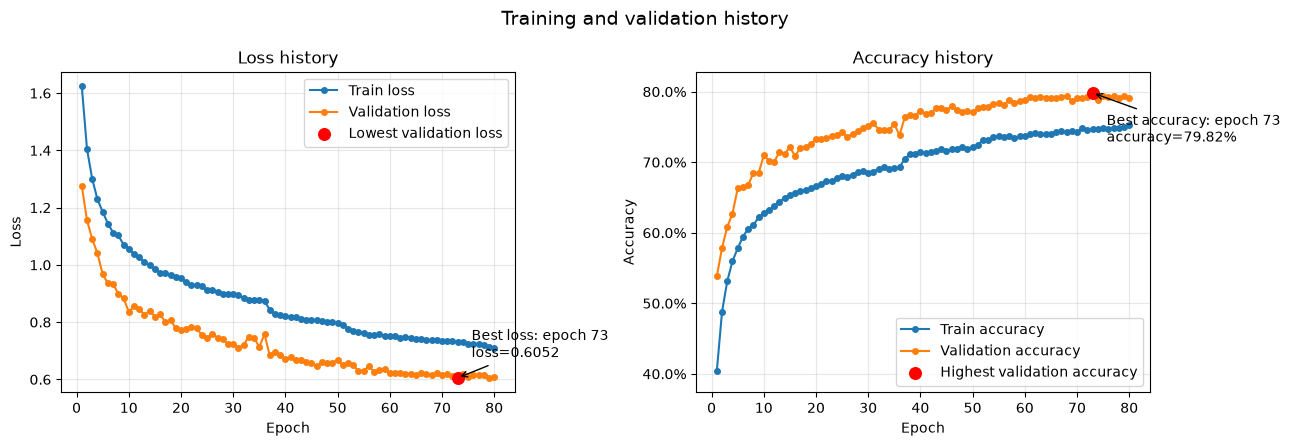

In [80]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# plot only completed epochs
# with early stopping, may stop before num_epochs
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)


# ============================================================
# Left plot: Train loss vs Validation loss
# ============================================================

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    markersize=4,
    label="Train loss"
)

axes[0].plot(
    epochs,
    history["validation_loss"],
    marker="o",
    markersize=4,
    label="Validation loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss history")
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# find epoch with lowest validation loss
# ------------------------------------------------------------

best_loss_index = history["validation_loss"].index(
    min(history["validation_loss"])
)

# index 0-based -> epoch 1-based
best_loss_epoch = best_loss_index + 1

best_validation_loss = history["validation_loss"][
    best_loss_index
]


# mark lowest validation loss
axes[0].scatter(
    best_loss_epoch,
    best_validation_loss,
    color="red",
    s=70,
    zorder=3,
    label="Lowest validation loss"
)

axes[0].annotate(
    f"Best loss: epoch {best_loss_epoch}\n"
    f"loss={best_validation_loss:.4f}",

    xy=(
        best_loss_epoch,
        best_validation_loss
    ),

    xytext=(10, 15),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

# legend after all artists
axes[0].legend()


# ============================================================
# Right plot: Train accuracy vs Validation accuracy
# ============================================================

axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    markersize=4,
    label="Train accuracy"
)

axes[1].plot(
    epochs,
    history["validation_accuracy"],
    marker="o",
    markersize=4,
    label="Validation accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy history")
axes[1].grid(alpha=0.3)


# show 0.75 as 75%
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)


# ------------------------------------------------------------
# zoom y-axis to accuracy range
# ------------------------------------------------------------

all_accuracies = (
    history["train_accuracy"]
    + history["validation_accuracy"]
)

accuracy_min = max(
    0.0,
    min(all_accuracies) - 0.03
)

accuracy_max = min(
    1.0,
    max(all_accuracies) + 0.03
)

axes[1].set_ylim(
    accuracy_min,
    accuracy_max
)


# ------------------------------------------------------------
# find epoch with highest validation accuracy
# ------------------------------------------------------------

best_accuracy_index = (
    history["validation_accuracy"].index(
        max(history["validation_accuracy"])
    )
)

best_accuracy_epoch = (
    best_accuracy_index + 1
)

best_validation_accuracy_from_history = (
    history["validation_accuracy"][
        best_accuracy_index
    ]
)


# mark best validation accuracy
axes[1].scatter(
    best_accuracy_epoch,
    best_validation_accuracy_from_history,
    color="red",
    s=70,
    zorder=3,
    label="Highest validation accuracy"
)

axes[1].annotate(
    f"Best accuracy: epoch {best_accuracy_epoch}\n"
    f"accuracy="
    f"{best_validation_accuracy_from_history:.2%}",

    xy=(
        best_accuracy_epoch,
        best_validation_accuracy_from_history
    ),

    xytext=(10, -35),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

axes[1].legend()


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Training and validation history",
    fontsize=14
)

fig.tight_layout()

plt.show()

In [81]:
"""
Standard model processing
"""
# import necessary package
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# use correct device
if torch.cuda.is_available():
    device = torch.device("cuda:0") 
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# setup hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 80

# setup transform of data: more generalized
train_transform = transforms.Compose([
    # pad 4px, then random crop back to 32x32
    # small random position shift
    transforms.RandomCrop(
        size=32,
        padding=4
    ),

    # horizontal flip with p=0.5
    transforms.RandomHorizontalFlip(),

    # PIL -> tensor, pixels in [0, 1]
    transforms.ToTensor(),

    # scale channels roughly from [0,1] to [-1,1]
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


# prepare CIFAR10 dataset
train_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=True,
    transform=train_transform
)
validation_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=True,
    download=False,
    transform=eval_transform
)
test_source = datasets.CIFAR10(
    root="data/cifar10_raw",
    train=False,
    download=False,
    transform=eval_transform
)
# split training and validation data
validation_size = 5000 # train_size = len(train_source) - validation_size
split_generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(
    len(train_source),
    generator=split_generator
)

validation_indices = all_indices[:validation_size]
train_indices = all_indices[validation_size:]

train_dataset = Subset(
    train_source,
    train_indices.tolist()
)
validation_dataset = Subset(
    validation_source,
    validation_indices.tolist()
)

# organize to DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_source,
    batch_size=batch_size,
    shuffle=False
)



# define class:
class CIFAR10DeeperCNN(nn.Module):
    # initation --- layers setup
    def __init__(self):
        super().__init__()

        # ===== Convolution block 1 =====
        self.block1 = nn.Sequential(
            # shape: (B, 3, 32, 32) => (B, 32, 32, 32)
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            # 32 channels
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),

            # shape: (B, 32, 32, 32) => (B, 32, 32, 32)
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            # 32 channels
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),

            # shape: (B, 32, 32, 32) => (B, 32, 16, 16)
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # ===== Convolution block 2 =====
        self.block2 = nn.Sequential(
            # shape: (B, 32, 16, 16) => (B, 64, 16, 16)
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            # 64 channels
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),

            # shape: (B, 64, 16, 16) => (B, 64, 16, 16)
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            # 64 channels
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),

            # shape: (B, 64, 16, 16) => (B, 64, 8, 8)
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # ===== Classifier =====
        self.classifier = nn.Sequential(
            # shape: (B, 64, 8, 8) => (B, 64 * 8 * 8) = (B, 4096)
            nn.Flatten(),

            # shape: (B, 4096) => (B, 128)
            nn.Linear(
                in_features=64 * 8 * 8,
                out_features=128
            ),
            nn.ReLU(),
            nn.Dropout(p=0.3), # drop 30% of hidden units to reduce co-adaptation

            # shape: (B, 128) => (B, 10)  # CIFAR-10: 10 class logits
            nn.Linear(
                in_features=128,
                out_features=10
            )
        )


    # put layers together
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        logits = self.classifier(x)
        return logits

# create model --- setup loss function and optimizer
model = CIFAR10DeeperCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    weight_decay=1e-4 # add weight_decay
) 

# Adjust learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    # watch validation loss (lower is better)
    mode="min",
    # on decay: new_lr = old_lr * 0.5
    factor=0.5,
    # decay if validation loss stalls for several epochs
    patience=4,
    # floor for learning rate
    min_lr=1e-5
)

# define training epoch function
def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device) # default = cpu
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        # sum each batch's loss
        current_batch_size = labels.size(0)
        total_loss += loss.item() * current_batch_size # multiply current_batch_size because loss.item() is the average of a batch.
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_samples += current_batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

# define evaluation function
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)
            predictions = logits.argmax(dim=1)
            # sum each batch's loss
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

        average_loss = total_loss / total_samples
        accuracy = total_correct / total_samples

    return average_loss, accuracy

# Save best model from validation datasets to "checkpoints"
from pathlib import Path
checkpoint_directory = Path("checkpoints")
checkpoint_directory.mkdir(
    parents=True,
    exist_ok=True
)
best_model_path = (
    checkpoint_directory /
    "best_cifar10_deeper_cnn.pth"
)
best_validation_accuracy = 0.0
best_epoch = 0

# history record
history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "learning_rate": []
}


for epoch in range(num_epochs):
    # lr used this epoch
    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    # train one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device
    )

    # evaluate on validation set
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        loss_fn,
        device
    )

    # record history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["learning_rate"].append(current_learning_rate)

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_epoch = epoch + 1
        torch.save(
            model.state_dict(),
            best_model_path
        )
        print(f"Saved new best model at epoch {best_epoch}")

    # print progress
    print(
        f"Epoch {epoch + 1}/{num_epochs}: "
        f"lr={current_learning_rate:.6f}, "
        f"train loss={train_loss:.4f}, "
        f"train accuracy={train_accuracy:.2%}, "
        f"validation loss={validation_loss:.4f}, "
        f"validation accuracy="
        f"{validation_accuracy:.2%}"
    )

    # maybe decay lr on validation loss plateau
    scheduler.step(validation_loss)
    next_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )  # lr after scheduler step
    if next_learning_rate < current_learning_rate:
        print(
            "Learning rate reduced: "
            f"{current_learning_rate:.6f} "
            f"-> {next_learning_rate:.6f}"
        )

# Use best model's parameters for test datasets
# Create same structure but with use different state of parameters
best_model = CIFAR10DeeperCNN() 
best_model_state = torch.load(
    best_model_path,
    map_location="cpu",
    weights_only=True
)
best_model.load_state_dict(
    best_model_state
)
best_model = best_model.to(device)
print("Best validation epoch:", best_epoch)
print(
    "Best validation accuracy:",
    f"{best_validation_accuracy:.2%}"
)


# test datasets
test_loss, test_accuracy = evaluate(
    best_model,
    test_loader,
    loss_fn,
    device
)
print("\nFinal test result:")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Using device: mps
Saved new best model at epoch 1
Epoch 1/80: lr=0.001000, train loss=1.6045, train accuracy=40.36%, validation loss=1.2678, validation accuracy=54.42%
Saved new best model at epoch 2
Epoch 2/80: lr=0.001000, train loss=1.2600, train accuracy=54.50%, validation loss=1.0004, validation accuracy=63.42%
Saved new best model at epoch 3
Epoch 3/80: lr=0.001000, train loss=1.1095, train accuracy=60.34%, validation loss=0.9960, validation accuracy=64.90%
Saved new best model at epoch 4
Epoch 4/80: lr=0.001000, train loss=1.0257, train accuracy=63.64%, validation loss=0.8215, validation accuracy=71.16%
Saved new best model at epoch 5
Epoch 5/80: lr=0.001000, train loss=0.9739, train accuracy=65.56%, validation loss=0.7736, validation accuracy=73.20%
Epoch 6/80: lr=0.001000, train loss=0.9280, train accuracy=67.32%, validation loss=0.8616, validation accuracy=69.50%
Epoch 7/80: lr=0.001000, train loss=0.8953, train accuracy=68.58%, validation loss=0.7886, validation accuracy=72.

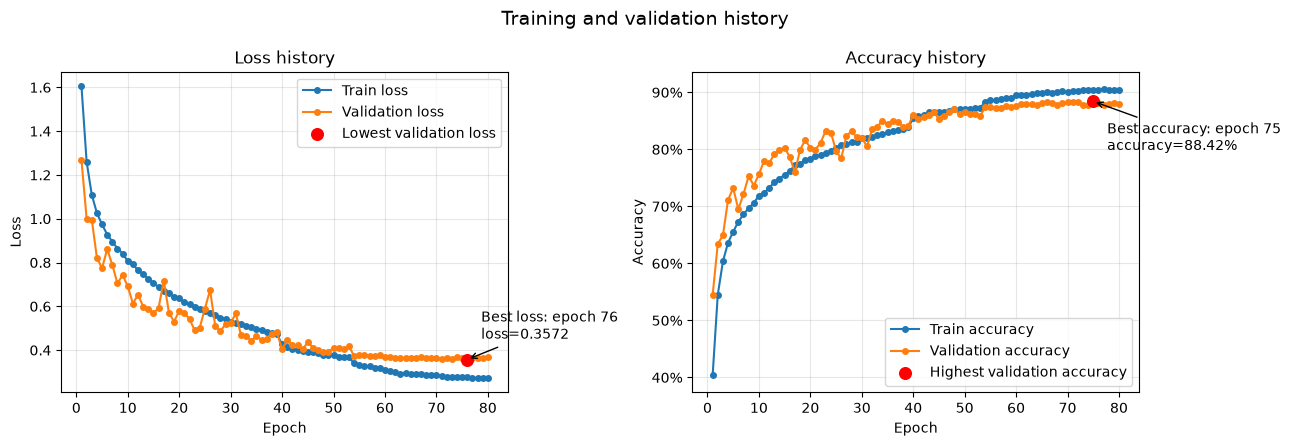

In [82]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# plot only completed epochs
# with early stopping, may stop before num_epochs
epochs = range(
    1,
    len(history["train_loss"]) + 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)


# ============================================================
# Left plot: Train loss vs Validation loss
# ============================================================

axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    markersize=4,
    label="Train loss"
)

axes[0].plot(
    epochs,
    history["validation_loss"],
    marker="o",
    markersize=4,
    label="Validation loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss history")
axes[0].grid(alpha=0.3)


# ------------------------------------------------------------
# find epoch with lowest validation loss
# ------------------------------------------------------------

best_loss_index = history["validation_loss"].index(
    min(history["validation_loss"])
)

# index 0-based -> epoch 1-based
best_loss_epoch = best_loss_index + 1

best_validation_loss = history["validation_loss"][
    best_loss_index
]


# mark lowest validation loss
axes[0].scatter(
    best_loss_epoch,
    best_validation_loss,
    color="red",
    s=70,
    zorder=3,
    label="Lowest validation loss"
)

axes[0].annotate(
    f"Best loss: epoch {best_loss_epoch}\n"
    f"loss={best_validation_loss:.4f}",

    xy=(
        best_loss_epoch,
        best_validation_loss
    ),

    xytext=(10, 15),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

# legend after all artists
axes[0].legend()


# ============================================================
# Right plot: Train accuracy vs Validation accuracy
# ============================================================

axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    markersize=4,
    label="Train accuracy"
)

axes[1].plot(
    epochs,
    history["validation_accuracy"],
    marker="o",
    markersize=4,
    label="Validation accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy history")
axes[1].grid(alpha=0.3)


# show 0.75 as 75%
axes[1].yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)


# ------------------------------------------------------------
# zoom y-axis to accuracy range
# ------------------------------------------------------------

all_accuracies = (
    history["train_accuracy"]
    + history["validation_accuracy"]
)

accuracy_min = max(
    0.0,
    min(all_accuracies) - 0.03
)

accuracy_max = min(
    1.0,
    max(all_accuracies) + 0.03
)

axes[1].set_ylim(
    accuracy_min,
    accuracy_max
)


# ------------------------------------------------------------
# find epoch with highest validation accuracy
# ------------------------------------------------------------

best_accuracy_index = (
    history["validation_accuracy"].index(
        max(history["validation_accuracy"])
    )
)

best_accuracy_epoch = (
    best_accuracy_index + 1
)

best_validation_accuracy_from_history = (
    history["validation_accuracy"][
        best_accuracy_index
    ]
)


# mark best validation accuracy
axes[1].scatter(
    best_accuracy_epoch,
    best_validation_accuracy_from_history,
    color="red",
    s=70,
    zorder=3,
    label="Highest validation accuracy"
)

axes[1].annotate(
    f"Best accuracy: epoch {best_accuracy_epoch}\n"
    f"accuracy="
    f"{best_validation_accuracy_from_history:.2%}",

    xy=(
        best_accuracy_epoch,
        best_validation_accuracy_from_history
    ),

    xytext=(10, -35),
    textcoords="offset points",

    arrowprops={
        "arrowstyle": "->"
    }
)

axes[1].legend()


# ============================================================
# Final layout
# ============================================================

fig.suptitle(
    "Training and validation history",
    fontsize=14
)

fig.tight_layout()

plt.show()